# Wordle: Gemma + LoRA + ES

Train a **linear head** on a Hugging Face causal LM with **Evolution Strategies**. This Week 11 notebook keeps the full **`google/gemma-3-1b-it`** path available, but now defaults to a **smoke-test profile** so you can verify the workflow quickly before committing to a long run. Switch `RUN_PROFILE` in §2 to move from fast validation to the fuller Gemma setup.

**Also:** Richer prompts with **structured constraints** from feedback; optional **supervised warm-start** (cross-entropy to the secret word; label only, not in the prompt).

**Requires:** `torch`, `transformers>=4.50.0`, `jinja2>=3.1.0` for chat-template models such as Gemma, `numpy`, `matplotlib`. **`pip install peft`** only if `USE_LORA=True` in §2. First run downloads HF weights.

## 1. Environment and imports

`peft` is **not** imported here (only needed for `USE_LORA=True`). Install it yourself if you enable LoRA.

**If you see `apply_chat_template requires jinja2>=3.1.0`:** run `python -m pip install -U 'jinja2>=3.1.0'` in the active notebook environment, then restart the kernel.

**If you see `unexpected keyword argument 'normalize_gradient'`:** restart the kernel and run this cell again, or rely on `importlib.reload` below (re-run this cell after editing `src/es_wordle.py`).

In [18]:
import os
import sys
import importlib
from pathlib import Path

import numpy as np
import torch

# Fall back to standard HF downloads; Xet caused import/download issues in this env.
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")

# Repo root + src on path (works from `notebooks/` or project root)
_here = Path.cwd().resolve()
ROOT = _here.parent if _here.name == "notebooks" else _here
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from wordle_env import load_wordle_environment
from wordle_gpt2_policy import WordleGPT2Policy, TRANSFORMERS_AVAILABLE

# Always pick up the latest es_wordle.py (Jupyter caches imports)
import es_wordle
importlib.reload(es_wordle)
from es_wordle import train_es_wordle, train_curriculum

import inspect
_sig = inspect.signature(train_es_wordle)
for _name in ("normalize_gradient", "eval_deterministic"):
    if _name not in _sig.parameters:
        raise RuntimeError(
            f"src/es_wordle.py is missing {_name}. Re-run the import cell after `importlib.reload`, or pull the latest repo."
        )

if not TRANSFORMERS_AVAILABLE:
    raise ImportError("Install transformers: pip install transformers")


def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    mps_backend = getattr(torch.backends, "mps", None)
    if mps_backend is not None and mps_backend.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def default_model_load_kwargs(device: torch.device) -> tuple[dict, str]:
    if device.type != "cuda":
        return {}, "float32"
    if torch.cuda.is_bf16_supported():
        return {"torch_dtype": torch.bfloat16}, "bfloat16"
    return {"torch_dtype": torch.float16}, "float16"


def _parse_version_tuple(version: str) -> tuple[int, ...]:
    parts = []
    for chunk in version.split("."):
        digits = ""
        for ch in chunk:
            if ch.isdigit():
                digits += ch
            else:
                break
        if not digits:
            break
        parts.append(int(digits))
    return tuple(parts)


def require_chat_template_support() -> None:
    try:
        import jinja2
    except ImportError as exc:
        raise ImportError(
            "Chat-template models require `jinja2>=3.1.0`. Install or upgrade it in the active notebook environment with `python -m pip install -U 'jinja2>=3.1.0'`, then restart the kernel."
        ) from exc

    installed = getattr(jinja2, "__version__", "0")
    if _parse_version_tuple(installed) < (3, 1, 0):
        raise ImportError(
            f"Chat-template models require `jinja2>=3.1.0`, but found {installed}. Upgrade it in the active notebook environment with `python -m pip install -U 'jinja2>=3.1.0'`, then restart the kernel."
        )


print("ROOT:", ROOT)
print("es_wordle:", es_wordle.__file__)
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())
print("HF_HUB_DISABLE_XET:", os.environ["HF_HUB_DISABLE_XET"])
if torch.cuda.is_available():
    print("cuda_device:", torch.cuda.get_device_name(0))

ROOT: /home/ubuntu/STAT-4830-project-base
es_wordle: /home/ubuntu/STAT-4830-project-base/src/es_wordle.py
torch: 2.11.0+cu130 | cuda: True
HF_HUB_DISABLE_XET: 1
cuda_device: NVIDIA A100 80GB PCIe


## 2. Hyperparameters

The next cell now supports two profiles:

- **`RUN_PROFILE="smoke"`**: fast validation path using a smaller model and short ES/warm-start settings.
- **`RUN_PROFILE="gemma_full"`**: restores the fuller Week 11 Gemma configuration for a real run.

Additional notes:

- **`MODEL_LOAD_KWARGS`**: automatically picks a GPU-friendly dtype on CUDA (`bfloat16` when supported, else `float16`). CPU stays on `float32`.
- **`USE_CHAT_TEMPLATE`**: stays enabled for Gemma instruction checkpoints and disabled for the smoke-test GPT-2 path.
- **`MOCK_ENV`**: remains `True` by default so validation runs stay bounded and always have the target word in the action set.
- **`N_POP` / `N_ITERATIONS` / `WARM_START_STEPS`**: are profile-controlled so the smoke path stays quick while the Gemma path keeps the heavier settings. `N_ITERATIONS` is now interpreted as iterations **per curriculum stage**.
- **`vocab_schedule`**: per-profile list of action-set sizes. `train_curriculum` runs ES at each size in turn, growing both the policy head and the env's secret pool together (see §5). The env is built with `target_pool=policy.words` so every episode is in-principle winnable. Use a single-element schedule (e.g. `[N]`) to disable curriculum.
- **`USE_LORA`**: still defaults to `False` so validation only trains the head unless you explicitly enable adapters.

In [19]:
# --- Hyperparameters (switch RUN_PROFILE for longer runs) ---

SEED = 42
RUN_PROFILE = "gemma_full"  # "smoke" or "gemma_full"
DEVICE = choose_device()

MOCK_ENV = False
USE_PRIME_TARGETS = True
USE_LORA = True  # Leave False for validation; enable only if you want PEFT adapters.
LORA_R = 4
RICHER_PROMPT = True
WARM_START_LR = 3e-4
SIGMA = 0.02
ALPHA = 0.12
NORMALIZE_GRADIENT = True
RANK_FITNESS = True
EVAL_DETERMINISTIC = True  # greedy eval: Success % reflects argmax policy (clearer after warm-start)
FITNESS_OBJECTIVE = "win_plus_return"
WIN_FITNESS_SCALE = 8.0

PROFILE_CONFIGS = {
    "smoke": {
        "model_name": "distilgpt2",
        "use_chat_template": False,
        "chat_generation_prompt": False,
        "max_prompt_length": 256,
        "vocab_schedule": [8],
        "n_eval_episodes": 1,
        "eval_n_episodes": 4,
        "eval_every": 1,
        "warm_start_steps": 12,
        "n_pop": 4,
        "n_iterations": 2,
        "num_train_examples": 128,
        "num_eval_examples": 16,
    },
    "gemma_full": {
        "model_name": "google/gemma-3-1b-it",
        "use_chat_template": True,
        "chat_generation_prompt": True,
        "max_prompt_length": 512,
        "vocab_schedule": [16, 32, 64, 96, 128, 256, 512, 1024],
        "n_eval_episodes": 2,
        "eval_n_episodes": 50,
        "eval_every": 1,
        "warm_start_steps": 400,
        "n_pop": 16,
        "n_iterations": 20,
        "num_train_examples": 2000,
        "num_eval_examples": 20,
    },
}

if RUN_PROFILE not in PROFILE_CONFIGS:
    raise ValueError(f"RUN_PROFILE must be one of {sorted(PROFILE_CONFIGS)}, got {RUN_PROFILE!r}")

cfg = PROFILE_CONFIGS[RUN_PROFILE]
MODEL_NAME = cfg["model_name"]
USE_CHAT_TEMPLATE = cfg["use_chat_template"]
if USE_CHAT_TEMPLATE:
    require_chat_template_support()
CHAT_GENERATION_PROMPT = cfg["chat_generation_prompt"]
MAX_PROMPT_LENGTH = cfg["max_prompt_length"]
N_EVAL_EPISODES = cfg["n_eval_episodes"]
EVAL_N_EPISODES = cfg["eval_n_episodes"]
EVAL_EVERY = cfg["eval_every"]
WARM_START_STEPS = cfg["warm_start_steps"]
N_POP = cfg["n_pop"]
N_ITERATIONS = cfg["n_iterations"]
NUM_TRAIN_EXAMPLES = cfg["num_train_examples"]
NUM_EVAL_EXAMPLES = cfg["num_eval_examples"]

# Mock: action space == secret pool only → every episode solvable; ES / eval see real wins.
if MOCK_ENV:
    from wordle_env import MOCK_WORDLE_TARGETS as _MOCK_T
    _MOCK_ACTIONS = len(_MOCK_T)
else:
    _MOCK_ACTIONS = None

# Curriculum vocabulary schedule: list of action-set sizes, monotonically growing.
# Each stage trains ES at its size, with the env's secret pool restricted to
# `policy.words` so every episode is in-principle winnable. With MOCK_ENV=True
# the schedule collapses to the mock action set so behaviour matches earlier
# notebooks.
if MOCK_ENV:
    VOCAB_SCHEDULE = [_MOCK_ACTIONS]
else:
    VOCAB_SCHEDULE = list(cfg["vocab_schedule"])

if not VOCAB_SCHEDULE:
    raise ValueError("vocab_schedule must contain at least one stage size.")
if any(b < a for a, b in zip(VOCAB_SCHEDULE, VOCAB_SCHEDULE[1:])):
    raise ValueError(f"vocab_schedule must be non-decreasing, got {VOCAB_SCHEDULE!r}")

INITIAL_VOCAB = VOCAB_SCHEDULE[0]
MAX_VOCAB = VOCAB_SCHEDULE[-1]
MODEL_LOAD_KWARGS, MODEL_DTYPE_NAME = default_model_load_kwargs(DEVICE)

import random

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = DEVICE
print(
    f"Profile: {RUN_PROFILE} | Model: {MODEL_NAME} | chat_template: {USE_CHAT_TEMPLATE} | LoRA: {USE_LORA}\n"
    f"  device={device}  model_dtype={MODEL_DTYPE_NAME}  MAX_PROMPT_LENGTH={MAX_PROMPT_LENGTH}\n"
    f"  vocab_schedule={VOCAB_SCHEDULE}  (initial={INITIAL_VOCAB}, max={MAX_VOCAB})\n"
    f"  ES: N_POP={N_POP}  N_ITERATIONS={N_ITERATIONS} per stage  n_eval_episodes={N_EVAL_EPISODES}  "
    f"eval_n_episodes={EVAL_N_EPISODES}  WARM_START_STEPS={WARM_START_STEPS}"
)
if MODEL_LOAD_KWARGS:
    print("model_load_kwargs:", MODEL_LOAD_KWARGS)

Profile: gemma_full | Model: google/gemma-3-1b-it | chat_template: True | LoRA: True
  device=cuda  model_dtype=bfloat16  MAX_PROMPT_LENGTH=512
  vocab_schedule=[16, 32, 64, 96, 128, 256, 512, 1024]  (initial=16, max=1024)
  ES: N_POP=16  N_ITERATIONS=20 per stage  n_eval_episodes=2  eval_n_episodes=50  WARM_START_STEPS=400
model_load_kwargs: {'torch_dtype': torch.bfloat16}


## 3. Build policy and environment

First execution downloads the tokenizer + weights for `MODEL_NAME` into the HF cache.

For `RUN_PROFILE="smoke"`, this should stay quick and use the small GPT-2 path. For `RUN_PROFILE="gemma_full"`, expect a larger download and a much heavier run.

`MODEL_LOAD_KWARGS` now passes a GPU-friendly dtype into the Hugging Face model loader when CUDA is available.

With `include_mock_targets_in_vocab=True` (default), the first actions include all `MOCK_WORDLE_TARGETS` so a random mock secret word is always in the action set.

Set `USE_LORA=True` in §2 for PEFT LoRA — run **`pip install peft`** before this cell. With `USE_LORA=False`, only the head is trained (faster ES).

In [20]:
policy = WordleGPT2Policy(
    model_name=MODEL_NAME,
    use_prime_targets=USE_PRIME_TARGETS,
    max_vocab_size=INITIAL_VOCAB,
    max_prompt_length=MAX_PROMPT_LENGTH,
    include_mock_targets_in_vocab=True,
    richer_prompt=RICHER_PROMPT,
    use_chat_template=USE_CHAT_TEMPLATE,
    chat_generation_prompt=CHAT_GENERATION_PROMPT,
    use_lora=USE_LORA,
    lora_r=LORA_R,
    model_kwargs=MODEL_LOAD_KWARGS,
).to(device)

from wordle_env import MOCK_WORDLE_TARGETS
assert all(w in policy.words for w in MOCK_WORDLE_TARGETS)

print(f"Trainable (ES): {policy.count_trainable_parameters():,}")
print(f"Total params:   {policy.count_parameters():,}")
print(f"Action dim:     {policy.action_dim} (initial; will grow to {MAX_VOCAB} across curriculum)")
print(f"Chat template:  {policy.use_chat_template}")
print(f"Load kwargs:    {MODEL_LOAD_KWARGS or {'torch_dtype': 'float32'}}")

# Pin env's secret pool to the policy's current action set so every episode is
# in-principle winnable. Curriculum stages will grow both in lockstep via
# train_curriculum -> env.set_target_pool(policy.words).
env = load_wordle_environment(
    num_train_examples=NUM_TRAIN_EXAMPLES,
    num_eval_examples=NUM_EVAL_EXAMPLES,
    use_prime_intellect=not MOCK_ENV,
    target_pool=policy.words,
)

[INFO] Using bundled Wordle answer list (2315 words); Prime Intellect not available (ModuleNotFoundError).


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Trainable (ES): 763,920
Total params:   1,000,649,872
Action dim:     16 (initial; will grow to 1024 across curriculum)
Chat template:  True
Load kwargs:    {'torch_dtype': torch.bfloat16}
[OK] Local Wordle environment ready (16 target words from explicit target_pool).


## 4. Optional supervised warm-start

Random play for 1–4 guesses, then **cross-entropy** toward the secret word (the answer is **not** in the prompt). Set `WARM_START_STEPS = 0` to skip.

In [21]:
# from wordle_gpt2_warmstart import supervised_warm_start_wordle

# if WARM_START_STEPS > 0:
#     ws = supervised_warm_start_wordle(
#         policy,
#         env,
#         n_steps=WARM_START_STEPS,
#         lr=WARM_START_LR,
#         device=device,
#         seed=SEED,
#         verbose=True,
#     )
#     print("Warm-start: fitted", len(ws["loss"]), "steps; skipped", ws["skipped"])
# else:
#     print("Skipping warm-start.")


## 5. Run ES training

`train_es_wordle` prints **every iteration** when `verbose=True`. **`‖θ−θ₀‖`** is the L2 distance of trainable weights from their **initial** values — it should **grow** every step (proof the optimizer is changing parameters). **`Step‖`** is often **constant** when `NORMALIZE_GRADIENT=True` (fixed step length by design). **`popσ`** is spread of fitness across the ES population (noise).

`history` now includes **`train_iter`, `train_fitness`, `param_drift`, `pop_fitness_std`, …** every iteration (not only eval checkpoints). The plot cell uses them in the **bottom row**.

Full eval lines (Success / Eval Reward) appear when `iteration % EVAL_EVERY == 0` or on the last iteration.

In [23]:
import gc
import random

from wordle_gpt2_warmstart import supervised_warm_start_wordle

LORA_R_CANDIDATES = [64, 128]

rank_results = {}
best_rank = None
best_final_success = float("-inf")
best_policy = None
best_history = None
best_env = None

if not USE_LORA:
    raise ValueError("LoRA rank sweep expects USE_LORA=True in hyperparameters.")

# Cell 3/4 may have created and warm-started a single-run policy.
# Drop it before sweeping ranks; each rank below creates a fresh policy and fresh env.
if "policy" in globals():
    del policy
if "ws" in globals():
    del ws
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

for rank in LORA_R_CANDIDATES:
    # Re-seed each run so rank-to-rank comparisons stay matched/reproducible.
    run_seed = int(SEED)
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run_seed)

    print(f"\n=== LoRA rank {rank} (seed={run_seed}) ===")

    run_policy = WordleGPT2Policy(
        model_name=MODEL_NAME,
        use_prime_targets=USE_PRIME_TARGETS,
        max_vocab_size=INITIAL_VOCAB,
        max_prompt_length=MAX_PROMPT_LENGTH,
        include_mock_targets_in_vocab=True,
        richer_prompt=RICHER_PROMPT,
        use_chat_template=USE_CHAT_TEMPLATE,
        chat_generation_prompt=CHAT_GENERATION_PROMPT,
        use_lora=USE_LORA,
        lora_r=rank,
        model_kwargs=MODEL_LOAD_KWARGS,
    ).to(device)

    # Env target pool starts aligned with the initial policy vocab; curriculum
    # stages call env.set_target_pool(policy.words) as the head grows.
    run_env = load_wordle_environment(
        num_train_examples=NUM_TRAIN_EXAMPLES,
        num_eval_examples=NUM_EVAL_EXAMPLES,
        use_prime_intellect=not MOCK_ENV,
        target_pool=run_policy.words,
    )

    run_history = train_curriculum(
        run_policy,
        run_env,
        vocab_schedule=VOCAB_SCHEDULE,
        n_iterations_per_stage=N_ITERATIONS,
        warm_start_fn=supervised_warm_start_wordle,
        warm_start_steps=WARM_START_STEPS,
        warm_start_kwargs={
            "lr": WARM_START_LR,
            "device": device,
            "seed": run_seed,
            "verbose": True,
        },
        N=N_POP,
        sigma=SIGMA,
        alpha=ALPHA,
        n_eval_episodes=N_EVAL_EPISODES,
        max_turns=6,
        eval_every=EVAL_EVERY,
        verbose=True,
        normalize_gradient=NORMALIZE_GRADIENT,
        eval_n_episodes=EVAL_N_EPISODES,
        rank_fitness=RANK_FITNESS,
        eval_deterministic=EVAL_DETERMINISTIC,
        fitness_objective=FITNESS_OBJECTIVE,
        win_fitness_scale=WIN_FITNESS_SCALE,
    )

    final_success = float(run_history["eval_success"][-1])
    rank_results[rank] = {
        "history": run_history,
        "final_success": final_success,
    }
    print(f"Final success probability (rank={rank}): {final_success:.3f}")

    if final_success > best_final_success:
        if best_policy is not None:
            del best_policy
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        best_rank = rank
        best_final_success = final_success
        best_policy = run_policy
        best_history = run_history
        best_env = run_env
    else:
        del run_policy
        del run_env
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

if best_rank is None:
    raise RuntimeError("No rank results were produced.")

policy = best_policy
history = best_history
env = best_env
LORA_R = best_rank

print("\nRank comparison (final success probability):")
for rank in LORA_R_CANDIDATES:
    print(f"  r={rank:>2}: {rank_results[rank]['final_success']:.3f}")
print(f"Selected best rank: r={best_rank} (success={best_final_success:.3f})")


=== LoRA rank 64 (seed=42) ===
[INFO] Using bundled Wordle answer list (2315 words); Prime Intellect not available (ModuleNotFoundError).


Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

[OK] Local Wordle environment ready (16 target words from explicit target_pool).

=== Curriculum stage 1/8 | vocab: 16 -> 16 (+0) ===
  warm-start 80/400 | loss=2.9550 | skipped=0
  warm-start 160/400 | loss=2.9494 | skipped=0
  warm-start 240/400 | loss=2.8464 | skipped=0
  warm-start 320/400 | loss=2.2408 | skipped=0
  warm-start 400/400 | loss=2.3927 | skipped=0
Warm-start (stage 1, vocab=16): fitted 400 steps; skipped 0
Iter    0 | Fit(win+ret):  8.767 | ES_win: 84.4% | popσ: 2.0783 | Eval Reward:  2.131 | Success: 100.0% (greedy) | Turns:  3.3 | Grad‖: 41831.34 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.12
Iter    1 | Fit(win+ret):  9.677 | ES_win: 93.8% | popσ: 1.4968 | Eval Reward:  2.099 | Success: 100.0% (greedy) | Turns:  3.1 | Grad‖: 41818.17 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.17
Iter    2 | Fit(win+ret):  9.380 | ES_win: 90.6% | popσ: 1.7500 | Eval Reward:  2.109 | Success: 100.0% (greedy) | Turns:  3.1 | Grad‖: 41831.65 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.21
Iter    3 | Fit(win+ret):  8.775 | ES_win: 8

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

[OK] Local Wordle environment ready (16 target words from explicit target_pool).

=== Curriculum stage 1/8 | vocab: 16 -> 16 (+0) ===
  warm-start 80/400 | loss=2.9435 | skipped=0
  warm-start 160/400 | loss=3.0170 | skipped=0
  warm-start 240/400 | loss=2.9220 | skipped=0
  warm-start 320/400 | loss=2.9340 | skipped=0
  warm-start 400/400 | loss=2.8817 | skipped=0
Warm-start (stage 1, vocab=16): fitted 400 steps; skipped 0
Iter    0 | Fit(win+ret):  3.923 | ES_win: 31.2% | popσ: 3.1526 | Eval Reward:  1.675 | Success: 48.0% (greedy) | Turns:  5.0 | Grad‖: 59144.50 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.12
Iter    1 | Fit(win+ret):  4.571 | ES_win: 37.5% | popσ: 2.9687 | Eval Reward:  1.419 | Success: 30.0% (greedy) | Turns:  5.1 | Grad‖: 59127.00 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.17
Iter    2 | Fit(win+ret):  5.653 | ES_win: 50.0% | popσ: 3.2037 | Eval Reward:  1.497 | Success: 36.0% (greedy) | Turns:  4.7 | Grad‖: 59134.67 | Step‖: 0.1200 | ‖θ-θ₀‖: 0.21
Iter    3 | Fit(win+ret):  3.673 | ES_win: 28.1

## 6. Plot training curves

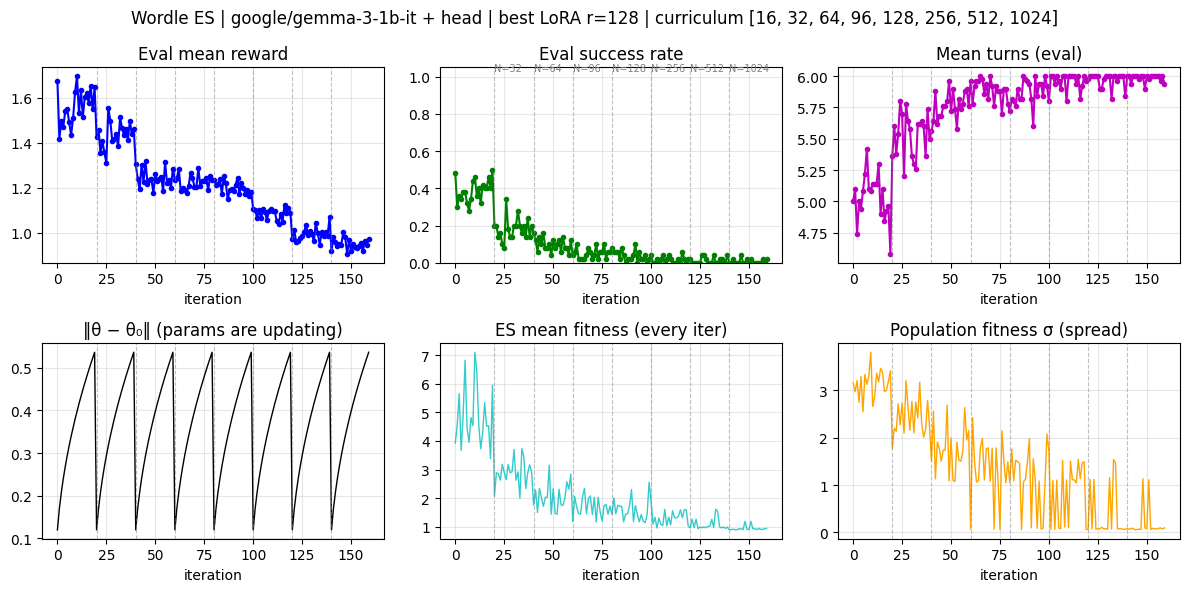

In [24]:
import matplotlib.pyplot as plt

it = history["iteration"]
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

axes[0, 0].plot(it, history["eval_reward"], "b-o", ms=3)
axes[0, 0].set_title("Eval mean reward")
axes[0, 0].set_xlabel("iteration")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(it, history["eval_success"], "g-o", ms=3)
axes[0, 1].set_title("Eval success rate")
axes[0, 1].set_xlabel("iteration")
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(it, history["eval_turns"], "m-o", ms=3)
axes[0, 2].set_title("Mean turns (eval)")
axes[0, 2].set_xlabel("iteration")
axes[0, 2].grid(True, alpha=0.3)

ti = history["train_iter"]
axes[1, 0].plot(ti, history["param_drift"], "k-", lw=1)
axes[1, 0].set_title("‖θ − θ₀‖ (params are updating)")
axes[1, 0].set_xlabel("iteration")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(ti, history["train_fitness"], "c-", lw=1, alpha=0.8)
axes[1, 1].set_title("ES mean fitness (every iter)")
axes[1, 1].set_xlabel("iteration")
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(ti, history["pop_fitness_std"], "orange", lw=1)
axes[1, 2].set_title("Population fitness σ (spread)")
axes[1, 2].set_xlabel("iteration")
axes[1, 2].grid(True, alpha=0.3)

# Overlay curriculum stage boundaries on every subplot (skip the first stage's
# marker at iteration 0 to avoid clutter at the y-axis).
stage_starts = history.get("stage_starts", [])
stage_vocab_sizes = history.get("stage_vocab_sizes", [])
for ax in axes.flat:
    for s_idx, s_iter in enumerate(stage_starts):
        if s_iter <= 0:
            continue
        ax.axvline(s_iter, color="gray", lw=0.8, ls="--", alpha=0.5)
        if ax is axes[0, 1] and s_idx < len(stage_vocab_sizes):
            ax.text(
                s_iter, 1.02, f"N={stage_vocab_sizes[s_idx]}",
                fontsize=7, color="gray", ha="left", va="bottom",
            )

rank_note = f" | best LoRA r={best_rank}" if "best_rank" in globals() else ""
schedule_note = (
    f" | curriculum {stage_vocab_sizes}" if len(stage_vocab_sizes) > 1 else ""
)
plt.suptitle(f"Wordle ES | {MODEL_NAME} + head{rank_note}{schedule_note}")
plt.tight_layout()
plt.show()

## 7. Save checkpoint (optional)

Saves the **head** plus `words` and `history` under `models/` at the repo root when `USE_LORA=False`.

When `USE_LORA=True`, checkpoint saving is skipped to avoid writing large LoRA model files.

In [25]:
if USE_LORA:
    if "best_rank" in globals():
        print(f"Best LoRA rank selected from sweep: r={best_rank}")
    print("Skipping checkpoint save for LoRA run to avoid large model artifacts.")
else:
    save_path = ROOT / "models" / f"wordle_gemma_es_head.{RUN_PROFILE}.pt"
    save_path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "head": policy.head.state_dict(),
        "model_name": MODEL_NAME,
        "words": policy.words,
        "history": history,
        "use_lora": USE_LORA,
        "run_profile": RUN_PROFILE,
        "model_load_kwargs": {k: str(v) for k, v in MODEL_LOAD_KWARGS.items()},
    }
    if getattr(policy, "_lm_trainable", False):
        payload["lm"] = policy.lm.state_dict()
    torch.save(payload, save_path)
    print("Saved:", save_path)

Best LoRA rank selected from sweep: r=128
Skipping checkpoint save for LoRA run to avoid large model artifacts.
